In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('urban_lifestyle_impact_dataset.csv')
df.head()

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,smoker_in_household,noise_pollution_level,use_of_air_purifiers,awareness_level,years_in_location,pollution_exposure_score,risk_category
0,54.9,NaN,Semi-Urban,1.0,Moderate,65.4,Factory,False,34.9,True,NaN,28.0,32.50,Medium
1,42.2,Public Only,Semi-Urban,5.0,High,41.8,NaN,False,89.6,False,Low,30.0,70.58,High
2,58.0,NaN,Urban,1.0,Low,65.0,Remote,False,53.6,False,Medium,26.0,41.57,Medium
3,75.5,Car,Semi-Urban,2.0,Moderate,64.4,Remote,False,27.1,False,High,22.0,43.97,Medium
4,40.3,NaN,Semi-Urban,1.0,High,52.9,Factory,True,27.2,False,Medium,24.0,38.08,Medium


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   daily_travel_time         8876 non-null   float64
 1   vehicle_ownership         6836 non-null   str    
 2   location_type             10000 non-null  str    
 3   nearby_industries         9205 non-null   float64
 4   green_space_access        9440 non-null   str    
 5   home_air_quality          10000 non-null  float64
 6   work_location_type        9347 non-null   str    
 7   smoker_in_household       10000 non-null  bool   
 8   noise_pollution_level     10000 non-null  float64
 9   use_of_air_purifiers      10000 non-null  bool   
 10  awareness_level           8985 non-null   str    
 11  years_in_location         9480 non-null   float64
 12  pollution_exposure_score  10000 non-null  float64
 13  risk_category             10000 non-null  str    
dtypes: bool(2), float6

In [22]:
df.describe()

,daily_travel_time,nearby_industries,home_air_quality,noise_pollution_level,years_in_location,pollution_exposure_score
count,8876.000000,9205.000000,10000.000000,10000.00000,9480.000000,10000.000000
mean,45.154439,1.987398,60.114330,50.12037,20.623312,44.092933
std,19.892298,1.416077,15.158124,20.04742,11.558152,12.071672
min,0.000000,0.000000,0.000000,0.00000,1.000000,5.970000
25%,31.600000,1.000000,49.800000,36.80000,11.000000,35.517500
50%,45.000000,2.000000,60.200000,50.10000,21.000000,43.690000
75%,58.525000,3.000000,70.500000,63.60000,31.000000,52.010000
max,123.500000,10.000000,100.000000,100.00000,40.000000,100.000000


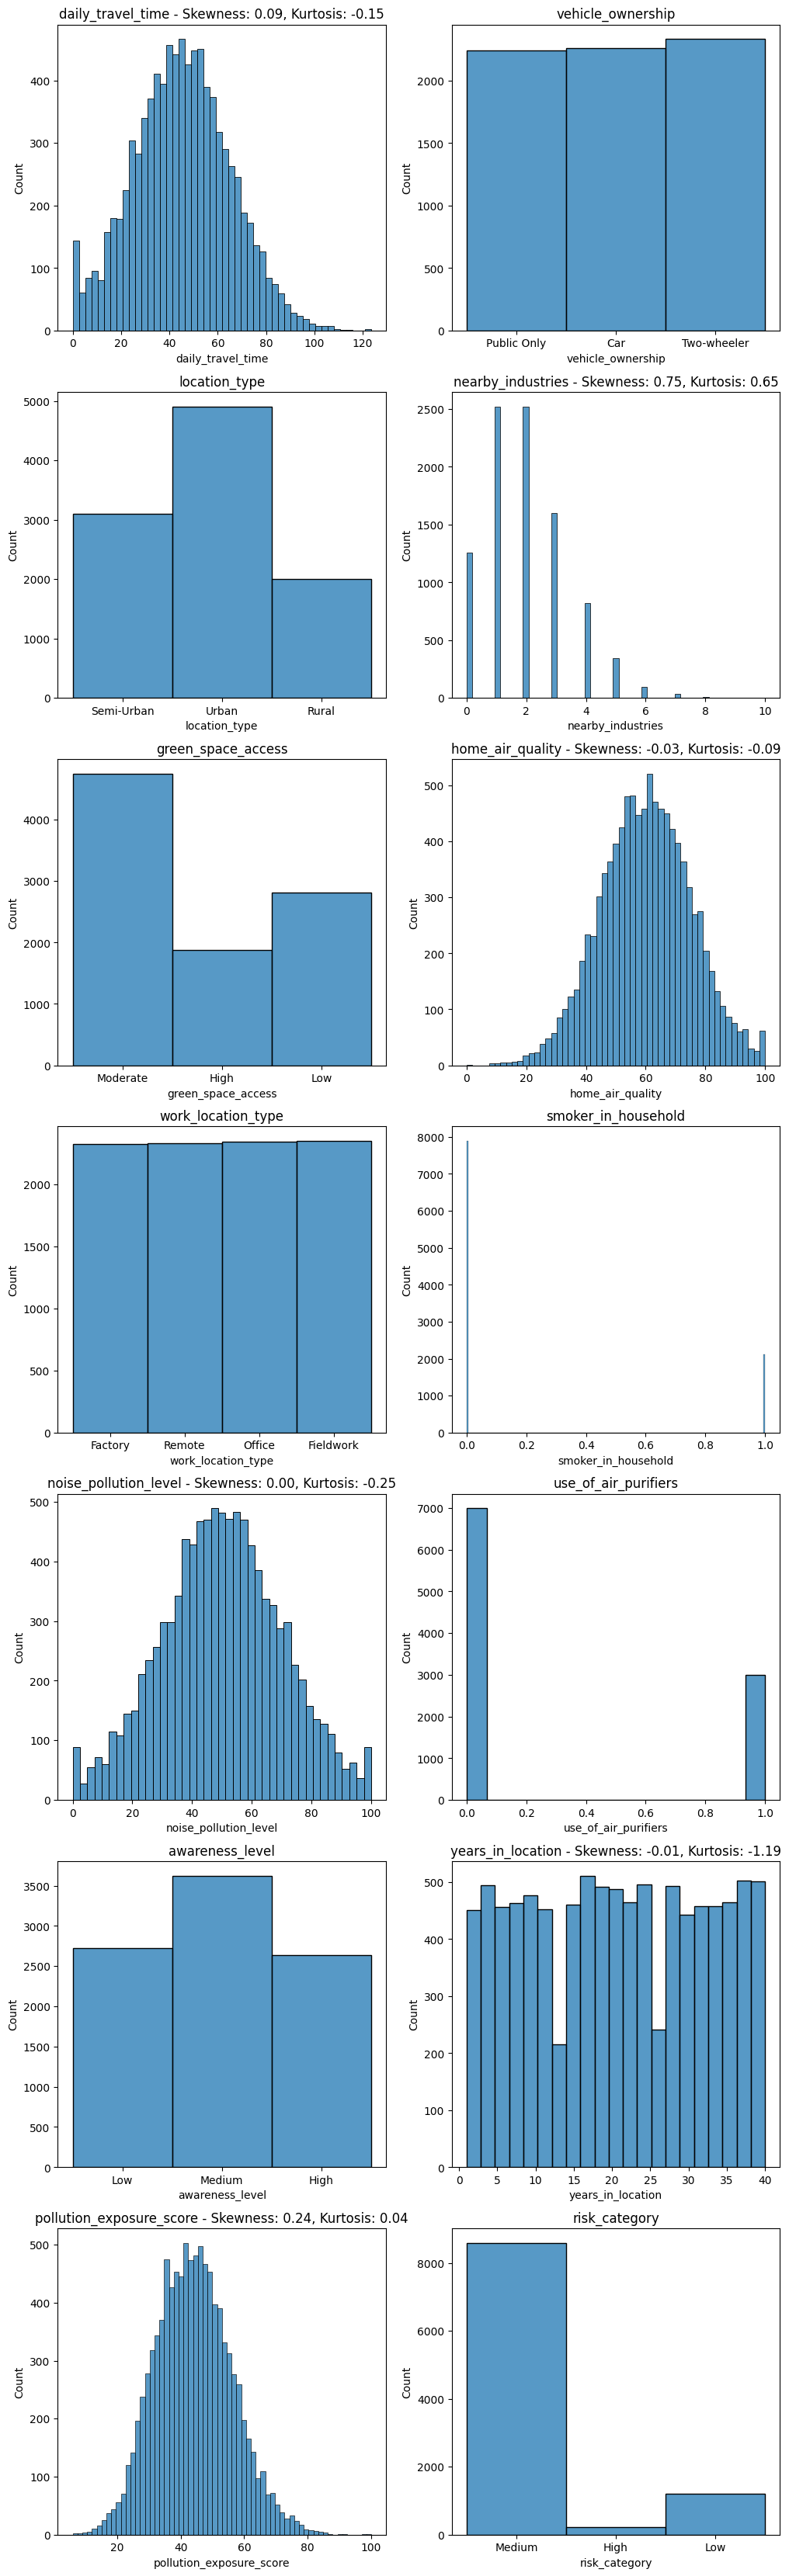

In [23]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots((len(df.columns) + 1) // 2, 2, figsize=(12, 6 * ((len(df.columns) + 1) // 2)))
for col, ax in zip(df.columns, axes.flat):
    sns.histplot(df[col], ax=ax)
    ax.set_title(col)
    if col in numeric_columns:
        # print(f'{col} - Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurtosis():.2f}')
        ax.set_title(f'{df[col].name} - Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurtosis():.2f}')
plt.show()

In [24]:
cardinality = df.nunique()
cardinality

daily_travel_time            968
vehicle_ownership              3
location_type                  3
nearby_industries             11
green_space_access             3
home_air_quality             802
work_location_type             4
smoker_in_household            2
noise_pollution_level        961
use_of_air_purifiers           2
awareness_level                3
years_in_location             40
pollution_exposure_score    4215
risk_category                  3
dtype: int64

In [25]:
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f'{col} - Unique values: {cardinality[col]}, - Top 5: {df[col].value_counts().head()}')

vehicle_ownership - Unique values: 3, - Top 5: vehicle_ownership
Two-wheeler    2333
Car            2259
Public Only    2244
Name: count, dtype: int64
location_type - Unique values: 3, - Top 5: location_type
Urban         4907
Semi-Urban    3094
Rural         1999
Name: count, dtype: int64
green_space_access - Unique values: 3, - Top 5: green_space_access
Moderate    4749
Low         2816
High        1875
Name: count, dtype: int64
work_location_type - Unique values: 4, - Top 5: work_location_type
Fieldwork    2349
Office       2341
Remote       2330
Factory      2327
Name: count, dtype: int64
awareness_level - Unique values: 3, - Top 5: awareness_level
Medium    3624
Low       2722
High      2639
Name: count, dtype: int64
risk_category - Unique values: 3, - Top 5: risk_category
Medium    8587
Low       1198
High       215
Name: count, dtype: int64


/tmp/ipykernel_33185/2946507780.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


Nota-se que nenhuma das colunas contém outliers.

Colunas já codificadas por _one-hot encoding_:

* `use_of_air_purifiers`
* `smoker_in_household`

Colunas categóricas não codificadas:

* `vehicle_ownership`
* `location_type`
* `green_space_access`
* `work_location_type`
* `awareness_level`
* `risk_category`

In [26]:
df['risk_category'].value_counts()

risk_category
Medium    8587
Low       1198
High       215
Name: count, dtype: int64

<Axes: xlabel='risk_category'>

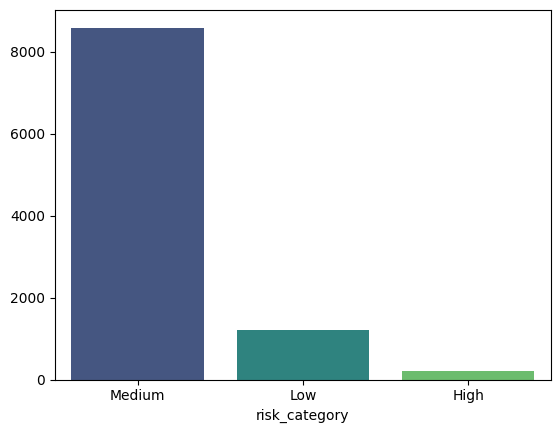

In [27]:
sns.barplot(x=df['risk_category'].value_counts().index, y=df['risk_category'].value_counts().values, palette='viridis', hue=df['risk_category'].value_counts().index, legend=False)

In [28]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler, OneHotEncoder

label_column = 'risk_category'
label_encoder = LabelEncoder()
label_encoder.fit(df[label_column])
labels = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
df[label_column] = label_encoder.transform(df[label_column])

def preprocess(df, standardize=True, encode_categorical=True, encode_onehot=False):
    if standardize:
        numeric_columns = ['daily_travel_time', 'nearby_industries', 'home_air_quality', 'noise_pollution_level', 'years_in_location']
        scaler = StandardScaler()
        df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

    if encode_categorical:
        categorical_columns = ['vehicle_ownership', 'location_type', 'green_space_access', 'work_location_type', 'awareness_level']
        ordinal_encoder = OrdinalEncoder()
        df[categorical_columns] = ordinal_encoder.fit_transform(df[categorical_columns])

    if encode_onehot:
        categorical_columns = ['vehicle_ownership', 'location_type', 'green_space_access', 'work_location_type', 'awareness_level']
        # ensure compatibility across sklearn versions
        try:
            onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)
        except TypeError:
            onehot_encoder = OneHotEncoder(drop='first', sparse=False)
        onehot_encoded = onehot_encoder.fit_transform(df[categorical_columns])
        onehot_df = pd.DataFrame(onehot_encoded, columns=onehot_encoder.get_feature_names_out(categorical_columns), index=df.index)
        df.drop(columns=categorical_columns, inplace=True)
        df = pd.concat([df, onehot_df], axis=1)

    return df

labels

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

In [29]:
df2 = df.copy()

In [30]:
df = preprocess(df, standardize=False)

<Axes: >

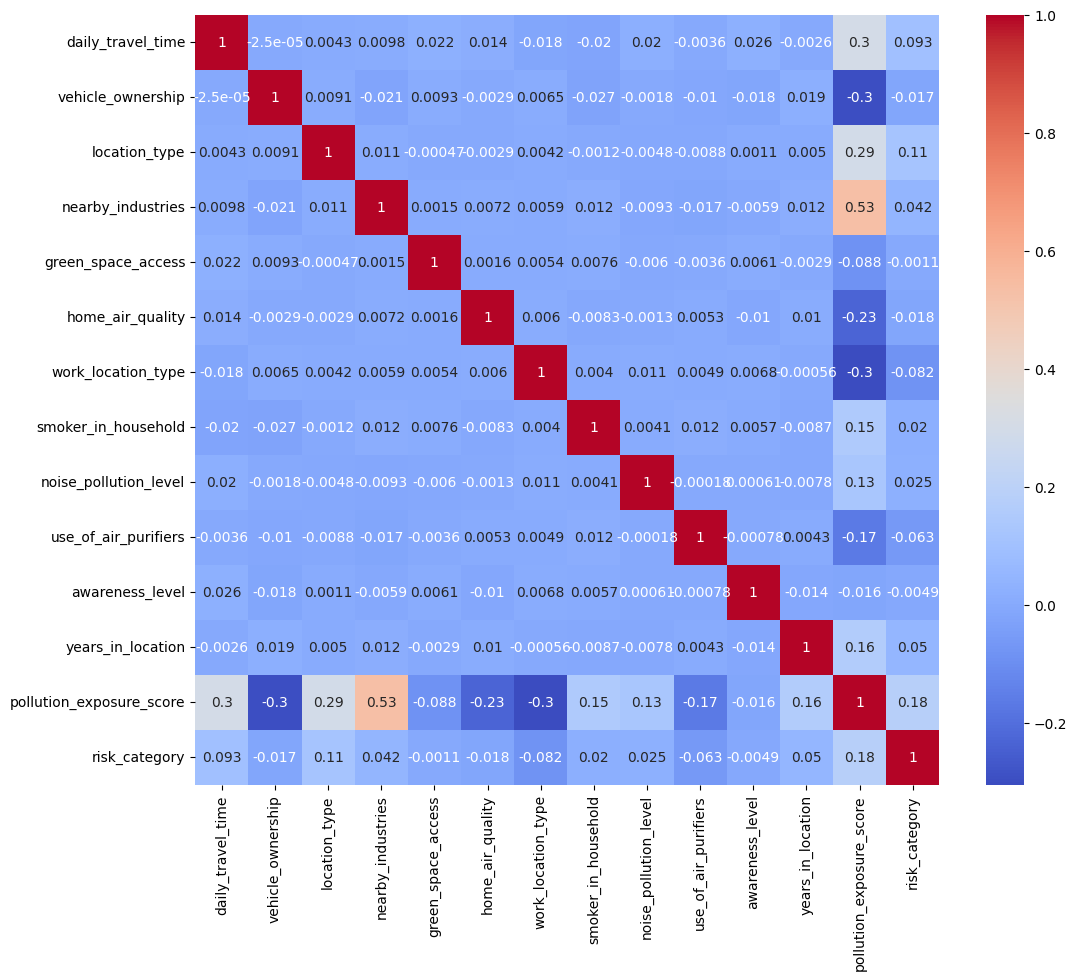

In [31]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

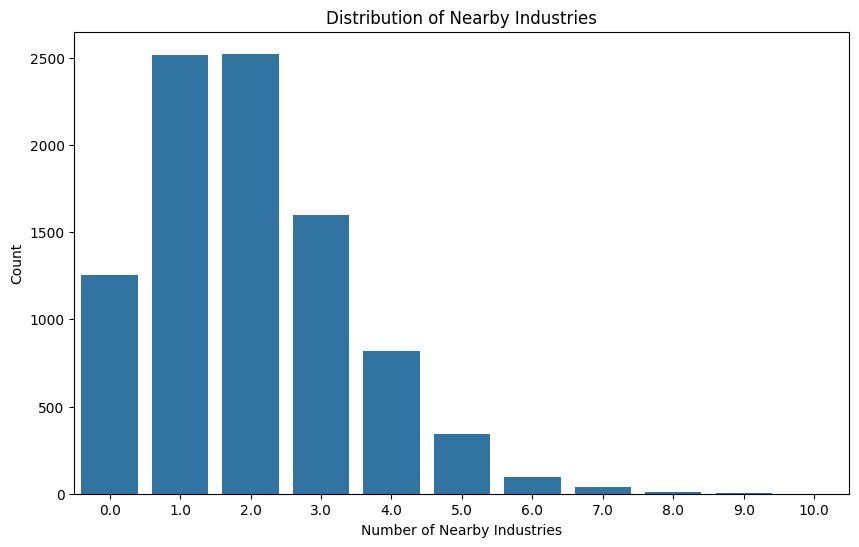

In [32]:
a = df['nearby_industries'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=a.index, y=a.values)
plt.xlabel('Number of Nearby Industries')
plt.ylabel('Count')
plt.title('Distribution of Nearby Industries')
plt.show()

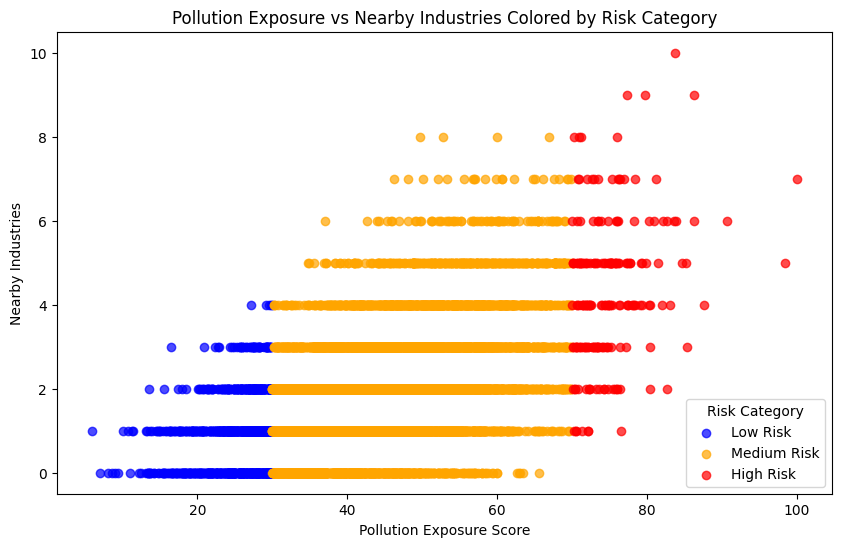

In [33]:
plt.figure(figsize=(10, 6))
low_risk = df[df['risk_category'] == labels['Low']]
medium_risk = df[df['risk_category'] == labels['Medium']]
high_risk = df[df['risk_category'] == labels['High']]
plt.scatter(low_risk['pollution_exposure_score'], low_risk['nearby_industries'], c='blue', label='Low Risk', alpha=0.7)
plt.scatter(medium_risk['pollution_exposure_score'], medium_risk['nearby_industries'], c='orange', label='Medium Risk', alpha=0.7)
plt.scatter(high_risk['pollution_exposure_score'], high_risk['nearby_industries'], c='red', label='High Risk', alpha=0.7)
plt.legend(title='Risk Category', loc='lower right')
plt.xlabel('Pollution Exposure Score')
plt.ylabel('Nearby Industries')
plt.title('Pollution Exposure vs Nearby Industries Colored by Risk Category')
plt.show()

Low-Medium Threshold: nan, Medium-High Threshold: nan


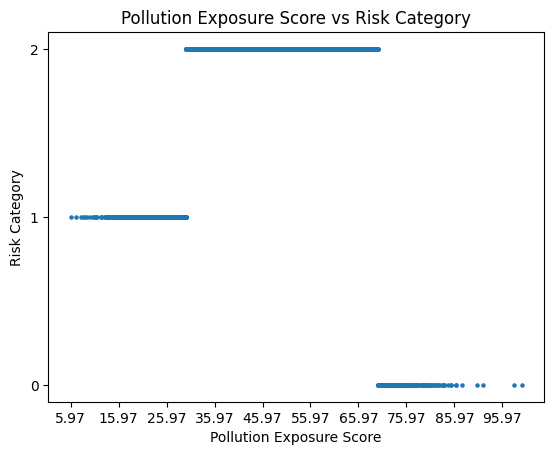

In [34]:
plt.scatter(df['pollution_exposure_score'], df['risk_category'], s=5)

# find the x value corresponding to the separation of risk categories
low_medium_threshold = df[df['risk_category'] == 'Medium']['pollution_exposure_score'].min()
medium_high_threshold = df[df['risk_category'] == 'High']['pollution_exposure_score'].min()
print(f'Low-Medium Threshold: {low_medium_threshold:.2f}, Medium-High Threshold: {medium_high_threshold:.2f}')
plt.axvline(x=low_medium_threshold, color='orange', linestyle='--')
plt.axvline(x=medium_high_threshold, color='red', linestyle='--')

plt.title('Pollution Exposure Score vs Risk Category')
plt.xlabel('Pollution Exposure Score')
plt.ylabel('Risk Category')
plt.xticks(ticks=np.arange(df['pollution_exposure_score'].min(), df['pollution_exposure_score'].max() + 1, 10))
plt.yticks(ticks=[0, 1, 2])
plt.show()

/tmp/ipykernel_33185/1528310979.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_counts.index, y=null_counts.values, palette='viridis')


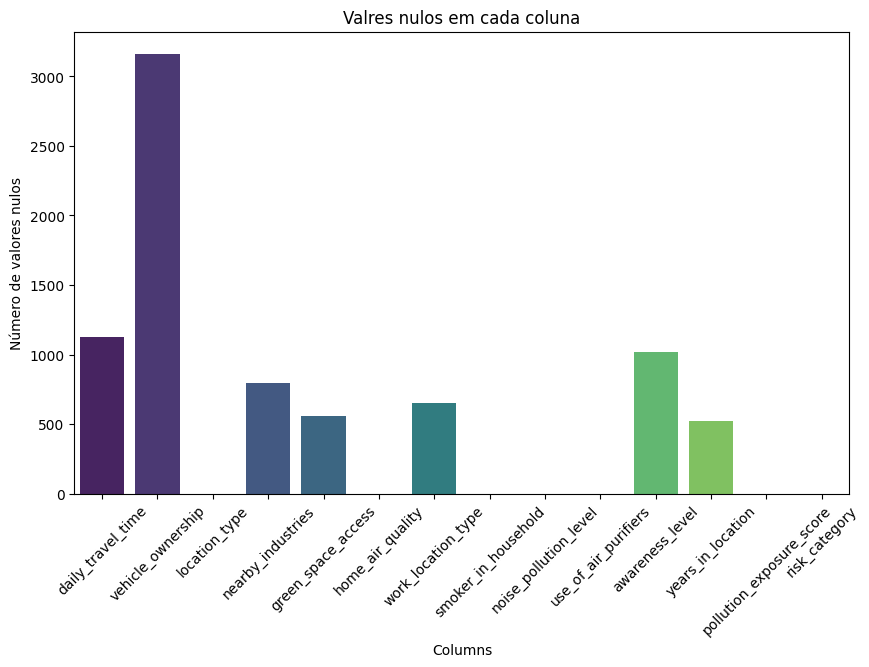

In [35]:
# plot the amount of null values in each column
null_counts = df.isnull().sum()
plt.figure(figsize=(10, 6))
sns.barplot(x=null_counts.index, y=null_counts.values, palette='viridis')
plt.xlabel('Columns')
plt.ylabel('Número de valores nulos')
plt.title('Valres nulos em cada coluna')
plt.xticks(rotation=45)
plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer

X, y = df.drop(columns=['risk_category', 'pollution_exposure_score']), df['risk_category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('classifier', RandomForestClassifier(random_state=42))
])

grid_search_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20],
    'classifier__min_samples_leaf': [5, 10],
    'classifier__class_weight': ['balanced', 'balanced_subsample'],
    'classifier__criterion': ['entropy']
}
grid_search = GridSearchCV(estimator=pipeline, param_grid=grid_search_params, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 score: {grid_search.best_score_:.4f}")
print(f"Test set F1 score with best parameters: {grid_search.score(X_test, y_test):.4f}")
print(f"Test set confusion matrix with best parameters:\n{confusion_matrix(y_test, grid_search.predict(X_test))}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END classifier__class_weight=balanced, classifier__criterion=entropy, classifier__max_depth=10, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time=   8.3s
[CV] END classifier__class_weight=balanced, classifier__criterion=entropy, classifier__max_depth=10, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time=   8.3s
[CV] END classifier__class_weight=balanced, classifier__criterion=entropy, classifier__max_depth=10, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time=   8.0s
[CV] END classifier__class_weight=balanced, classifier__criterion=entropy, classifier__max_depth=10, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time=  10.3s
[CV] END classifier__class_weight=balanced, classifier__criterion=entropy, classifier__max_depth=10, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time=  10.0s
[CV] END classifier__class_we

In [37]:
class_results = pd.DataFrame(grid_search.cv_results_).sort_values('mean_test_score', ascending=False)
class_results[['param_classifier__n_estimators', 'param_classifier__max_depth', 'param_classifier__min_samples_leaf', 'param_classifier__class_weight', 'param_classifier__criterion', 'mean_test_score']].head(10)

,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_leaf,param_classifier__class_weight,param_classifier__criterion,mean_test_score
7,200,20,10,balanced,entropy,0.724118
6,100,20,10,balanced,entropy,0.723308
14,100,20,10,balanced_subsample,entropy,0.719108
15,200,20,10,balanced_subsample,entropy,0.719053
12,100,20,5,balanced_subsample,entropy,0.711317
2,100,10,10,balanced,entropy,0.711113
5,200,20,5,balanced,entropy,0.709999
3,200,10,10,balanced,entropy,0.709714
13,200,20,5,balanced_subsample,entropy,0.707066
0,100,10,5,balanced,entropy,0.705955


              precision    recall  f1-score   support

        High       0.52      0.56      0.54        43
         Low       0.61      0.79      0.69       240
      Medium       0.96      0.92      0.94      1717

    accuracy                           0.89      2000
   macro avg       0.70      0.75      0.72      2000
weighted avg       0.91      0.89      0.90      2000



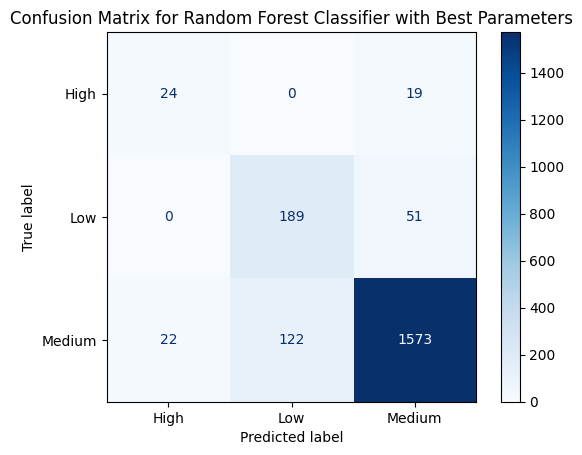

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


preds = grid_search.predict(X_test)
report = classification_report(y_test, preds, target_names=label_encoder.classes_, zero_division=0)
print(report)
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Random Forest Classifier with Best Parameters')
plt.show()

In [39]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, grid_search.predict_proba(X_test), multi_class='ovr')
print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.9494


# Rede Neural

In [40]:
df2 = preprocess(df2, standardize=True, encode_categorical=False, encode_onehot=True)

In [41]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   daily_travel_time              8876 non-null   float64
 1   nearby_industries              9205 non-null   float64
 2   home_air_quality               10000 non-null  float64
 3   smoker_in_household            10000 non-null  bool   
 4   noise_pollution_level          10000 non-null  float64
 5   use_of_air_purifiers           10000 non-null  bool   
 6   years_in_location              9480 non-null   float64
 7   pollution_exposure_score       10000 non-null  float64
 8   risk_category                  10000 non-null  int64  
 9   vehicle_ownership_Public Only  10000 non-null  float64
 10  vehicle_ownership_Two-wheeler  10000 non-null  float64
 11  vehicle_ownership_nan          10000 non-null  float64
 12  location_type_Semi-Urban       10000 non-null  float64
 13

In [42]:
df.describe()

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,noise_pollution_level,awareness_level,years_in_location,pollution_exposure_score,risk_category
count,8876.000000,6836.000000,10000.000000,9205.000000,9440.000000,10000.000000,9347.000000,10000.00000,8985.000000,9480.000000,10000.000000,10000.000000
mean,45.154439,1.010825,1.290800,1.987398,1.304449,60.114330,1.500053,50.12037,1.109627,20.623312,44.092933,1.837200
std,19.892298,0.819585,0.778522,1.416077,0.780429,15.158124,1.116514,20.04742,0.827713,11.558152,12.071672,0.423455
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,5.970000,0.000000
25%,31.600000,0.000000,1.000000,1.000000,1.000000,49.800000,1.000000,36.80000,0.000000,11.000000,35.517500,2.000000
50%,45.000000,1.000000,1.000000,2.000000,2.000000,60.200000,1.000000,50.10000,1.000000,21.000000,43.690000,2.000000
75%,58.525000,2.000000,2.000000,3.000000,2.000000,70.500000,2.000000,63.60000,2.000000,31.000000,52.010000,2.000000
max,123.500000,2.000000,2.000000,10.000000,2.000000,100.000000,3.000000,100.00000,2.000000,40.000000,100.000000,2.000000


In [43]:
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('classifier', MLPClassifier(random_state=42))
])
mlp_grid_search_params = {
    'classifier__hidden_layer_sizes': [(60,), (30, 30), (120,), (200,)],
    'classifier__activation': ['tanh'],
    'classifier__alpha': [0.0001, 0.001],
    'classifier__max_iter': [500],
}
mlp_grid_search = GridSearchCV(estimator=mlp_pipeline, param_grid=mlp_grid_search_params, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)
mlp_grid_search.fit(X_train, y_train)
print(f"Best parameters: {mlp_grid_search.best_params_}")
print(f"Best F1 score: {mlp_grid_search.best_score_:.4f}")
print(f"Test set F1 score with best parameters: {mlp_grid_search.score(X_test, y_test):.4f}")
print(f"Test set confusion matrix with best parameters:\n{confusion_matrix(y_test, mlp_grid_search.predict(X_test))}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END classifier__activation=tanh, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(30, 30), classifier__max_iter=500; total time=  12.5s
[CV] END classifier__activation=tanh, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(30, 30), classifier__max_iter=500; total time=  15.3s
[CV] END classifier__activation=tanh, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(30, 30), classifier__max_iter=500; total time=  19.9s
[CV] END classifier__activation=tanh, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(30, 30), classifier__max_iter=500; total time=  23.0s
[CV] END classifier__activation=tanh, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(60,), classifier__max_iter=500; total time=  26.1s
[CV] END classifier__activation=tanh, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(60,), classifier__max_iter=500; total time=  26.8s
[CV] END classifier__activation=tanh, classifi

In [44]:
pd.DataFrame(mlp_grid_search.cv_results_).sort_values('mean_test_score', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__activation,param_classifier__alpha,param_classifier__hidden_layer_sizes,param_classifier__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
7,44.254623,4.930771,0.275905,0.031966,tanh,0.0010,"(200,)",500,"{'classifier__activation': 'tanh', 'classifier...",0.709092,0.731805,0.715166,0.673416,0.660598,0.698015,0.026698,1
6,38.618544,3.824701,0.570500,0.088467,tanh,0.0010,"(120,)",500,"{'classifier__activation': 'tanh', 'classifier...",0.706972,0.724046,0.691042,0.689959,0.666021,0.695608,0.019319,2
2,39.109542,7.494705,0.987451,0.230743,tanh,0.0001,"(120,)",500,"{'classifier__activation': 'tanh', 'classifier...",0.722786,0.741836,0.681327,0.684565,0.642146,0.694532,0.034797,3
4,27.810983,3.339677,0.876883,0.225741,tanh,0.0010,"(60,)",500,"{'classifier__activation': 'tanh', 'classifier...",0.733721,0.713875,0.701643,0.683421,0.634096,0.693351,0.033851,4
0,29.845952,3.966280,0.844855,0.079181,tanh,0.0001,"(60,)",500,"{'classifier__activation': 'tanh', 'classifier...",0.718951,0.678785,0.710678,0.694552,0.663595,0.693312,0.020271,5
3,57.169944,11.434389,1.008091,0.179897,tanh,0.0001,"(200,)",500,"{'classifier__activation': 'tanh', 'classifier...",0.709838,0.714812,0.676167,0.689930,0.646489,0.687447,0.024743,6
1,20.824443,8.548087,0.726918,0.093349,tanh,0.0001,"(30, 30)",500,"{'classifier__activation': 'tanh', 'classifier...",0.713361,0.672496,0.624488,0.693167,0.556230,0.651948,0.056229,7
5,15.641854,10.043568,1.111865,0.290108,tanh,0.0010,"(30, 30)",500,"{'classifier__activation': 'tanh', 'classifier...",0.662647,0.695699,0.586024,0.595786,0.583647,0.624761,0.045821,8


              precision    recall  f1-score   support

           0       0.73      0.44      0.55        43
           1       0.79      0.57      0.67       240
           2       0.93      0.97      0.95      1717

    accuracy                           0.92      2000
   macro avg       0.82      0.66      0.72      2000
weighted avg       0.91      0.92      0.91      2000



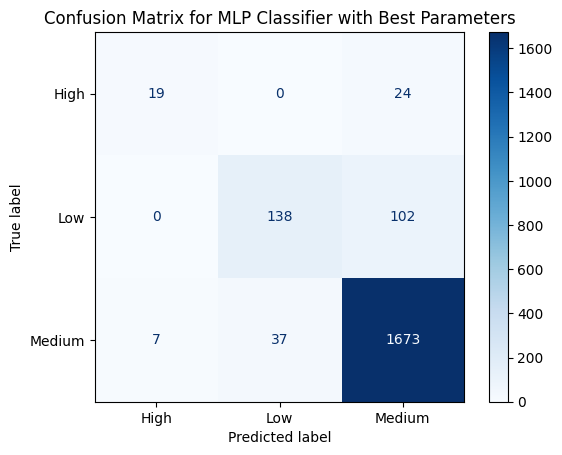

In [45]:
preds = mlp_grid_search.predict(X_test)
report = classification_report(y_test, preds, zero_division=0)
print(report)
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for MLP Classifier with Best Parameters')
plt.show()